# Generación Monte Carlo de combinaciones de rugosidad de Manning

Caso de estudio: **Río Besaya — Corrales de Buelna** (EPSG:25830)

Objetivo: construir 1.000 combinaciones estocásticas de coeficientes de Manning
para 9 tipos de uso del suelo, a partir de valores bibliográficos (Chow 1959,
USGS, FHWA, Brater & King, Barnes).  
Cada combinación se usará como entrada a una simulación hidráulica independiente
(SFINCS o HEC-RAS).

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy.stats as stats

from pyhydra.modeling.hydraulic.sensitivity import generate_manning_combinations

## Rutas — ajustar según el entorno

In [2]:
DATA_DIR   = Path("/Volumes/My Passport 2/OneDrive/Scripts_Python/Paper_Rugosidades")
OUTPUT_DIR = Path("/Volumes/My Passport 2/COPIA_IH/E/Rugosidades_UCLM/Ejemplo_Besaya/nsim_rugos")

MANNING_DIST_CSV    = DATA_DIR / "manning_roughness_coefficients_dist.csv"
COMBINATIONS_CSV    = DATA_DIR / "combinaciones_rugosidad.csv"
MANNING_BASE_CSV    = Path("/Volumes/My Passport 2/COPIA_IH/E/Rugosidades_UCLM/Ejemplo_Besaya/manning.csv")

N_SAMPLES = 1000
SEED      = 42

## 1 · Valores bibliográficos de Manning por uso del suelo

In [3]:
df_dist = pd.read_csv(MANNING_DIST_CSV, index_col=0)
df_dist.head()

,Manning,Descripción,Landuse,N
0,1,Trees,1,"0.10, 0.12, 0.15, 0.16, 0.18, 0.20, 0.25"
1,2,Dense vegetation,2,"0.06, 0.08, 0.09, 0.10, 0.11, 0.12, 0.14"
2,4,Urban vegetation,4,"0.05, 0.06, 0.07, 0.08, 0.10, 0.12, 0.13"
3,5,Infrastructure,5,"0.011, 0.012, 0.013, 0.015, 0.017, 0.018, 0.020"
4,6,Sparse vegetation,6,"0.02, 0.03, 0.04, 0.05, 0.06, 0.07, 0.08"


## 2 · Ajuste de distribuciones y simulación Monte Carlo

Para cada tipo de uso del suelo se ajusta la mejor distribución entre
normal, lognormal y gamma (criterio: mayor p-valor KS), se generan
10.000 muestras y se seleccionan 1.000 sin reemplazamiento.

In [4]:
combinaciones_df = generate_manning_combinations(
    manning_dist_csv=str(MANNING_DIST_CSV),
    n_samples=N_SAMPLES,
    mc_size=10_000,
    seed=SEED,
)
print(f"Combinaciones generadas: {combinaciones_df.shape}")
combinaciones_df.head()

Combinaciones generadas: (1000, 9)


,Trees,Dense vegetation,Urban vegetation,Infrastructure,Sparse vegetation,Residential,Industrial,River,Brushland
0,0.212618,0.063621,0.048980,0.016859,0.048122,0.013347,0.014068,0.029359,0.084355
1,0.181537,0.101495,0.109873,0.013668,0.054543,0.013915,0.015766,0.043806,0.091301
2,0.141517,0.079168,0.053750,0.017688,0.054742,0.017233,0.020753,0.034549,0.058733
3,0.177430,0.133620,0.116314,0.009746,0.011417,0.010516,0.019036,0.048058,0.059916
4,0.192496,0.151237,0.101102,0.015310,0.050504,0.014796,0.019745,0.056182,0.042645


## 3 · Visualización de distribuciones ajustadas

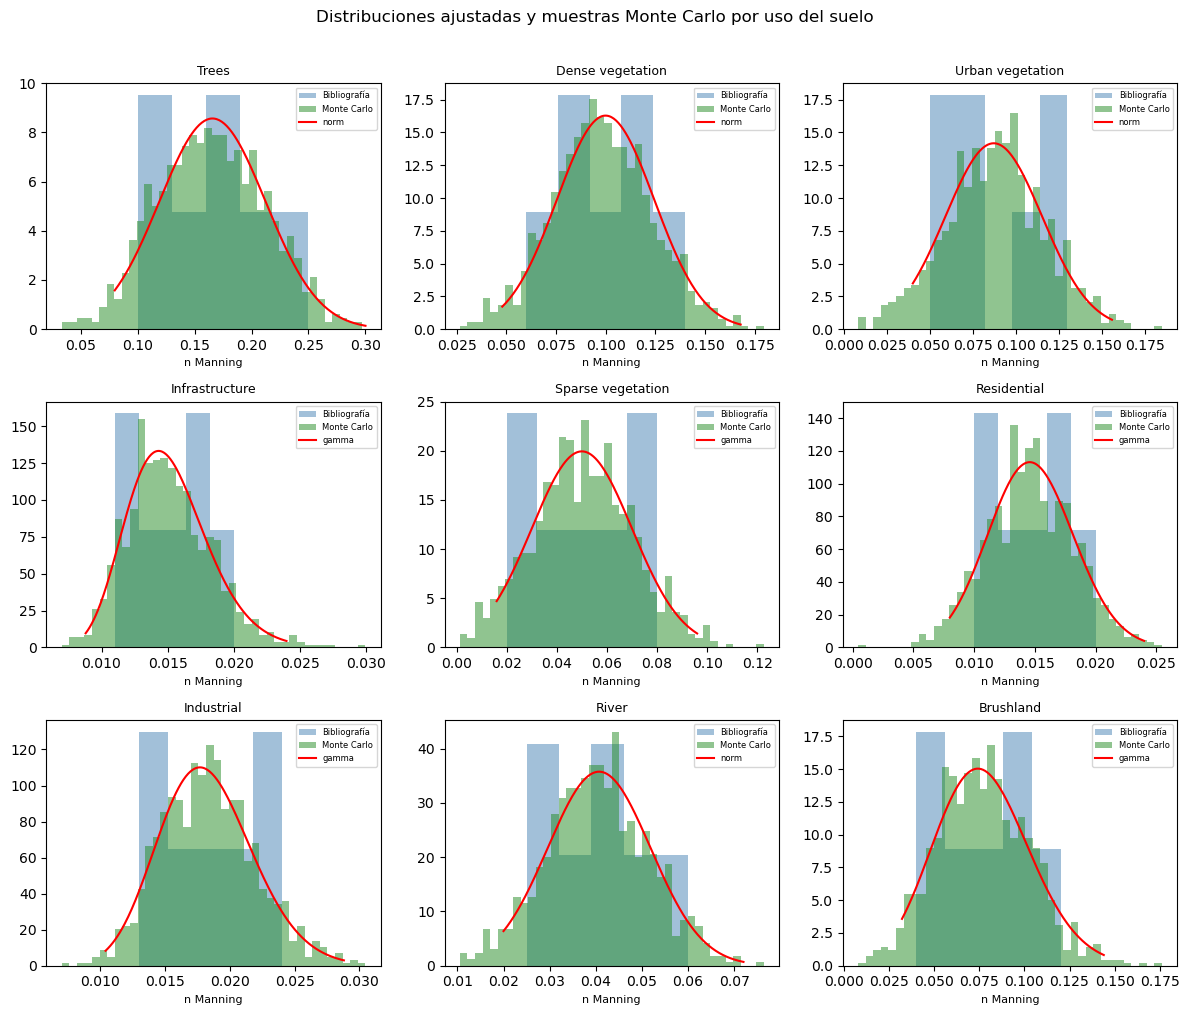

In [5]:
from pyhydra.modeling.hydraulic.sensitivity import _best_distribution

fig, axes = plt.subplots(3, 3, figsize=(12, 10))
axes = axes.flatten()

plot_idx = 0
for _, row in df_dist.iterrows():
    if str(row["N"]) == "-999":
        continue
    values = np.array([float(v) for v in str(row["N"]).split(",")])
    land_use = row["Descripción"]

    best_dist, best_params = _best_distribution(values)
    dist = getattr(stats, best_dist)

    ax = axes[plot_idx]
    ax.hist(values, bins=5, density=True, alpha=0.5, color="steelblue", label="Bibliografía")
    ax.hist(combinaciones_df[land_use], bins=40, density=True, alpha=0.5,
            color="forestgreen", label="Monte Carlo")

    x = np.linspace(values.min() * 0.8, values.max() * 1.2, 200)
    pdf = dist.pdf(x, *best_params[:-2], loc=best_params[-2], scale=best_params[-1])
    ax.plot(x, pdf, "r-", lw=1.5, label=f"{best_dist}")

    ax.set_title(land_use, fontsize=9)
    ax.set_xlabel("n Manning", fontsize=8)
    ax.legend(fontsize=6)
    plot_idx += 1

plt.suptitle("Distribuciones ajustadas y muestras Monte Carlo por uso del suelo", y=1.01)
plt.tight_layout()
plt.show()

## 4 · Guardar combinaciones y CSVs individuales por simulación

In [6]:
# Guardar tabla maestra de combinaciones
combinaciones_df.to_csv(COMBINATIONS_CSV, index=False)
print(f"Guardado: {COMBINATIONS_CSV}")

Guardado: /Volumes/My Passport 2/OneDrive/Scripts_Python/Paper_Rugosidades/combinaciones_rugosidad.csv


In [7]:
# Cargar tabla base de Manning (mapeo landuse_code → descripción)
df_base = pd.read_csv(MANNING_BASE_CSV)

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# La última columna de combinaciones_df es NoData → N = -9999
for i in range(N_SAMPLES):
    n_values = combinaciones_df.iloc[i].tolist() + [-9999]
    out = pd.DataFrame({
        "manning":     df_base["manning"].tolist(),
        "description": df_base["description"].tolist(),
        "landuse":     df_base["landuse"].tolist(),
        "N":           n_values,
    })
    out.to_csv(OUTPUT_DIR / f"combinacion_{i + 1}.csv", index=False)

print(f"Generados {N_SAMPLES} CSVs en {OUTPUT_DIR}")

Generados 1000 CSVs en /Volumes/My Passport 2/COPIA_IH/E/Rugosidades_UCLM/Ejemplo_Besaya/nsim_rugos


## 5 · Estadísticos de las combinaciones generadas

In [8]:
combinaciones_df.describe().round(4)

,Trees,Dense vegetation,Urban vegetation,Infrastructure,Sparse vegetation,Residential,Industrial,River,Brushland
count,1000.0000,1000.0000,1000.0000,1000.0000,1000.0000,1000.0000,1000.0000,1000.0000,1000.0000
mean,0.1650,0.0982,0.0879,0.0151,0.0504,0.0146,0.0183,0.0404,0.0771
std,0.0470,0.0249,0.0286,0.0032,0.0199,0.0036,0.0037,0.0110,0.0258
min,0.0333,0.0266,0.0080,0.0070,0.0013,0.0004,0.0070,0.0105,0.0076
25%,0.1311,0.0810,0.0691,0.0129,0.0371,0.0121,0.0156,0.0331,0.0585
50%,0.1646,0.0973,0.0886,0.0148,0.0506,0.0146,0.0182,0.0403,0.0764
75%,0.1989,0.1150,0.1063,0.0171,0.0634,0.0171,0.0207,0.0477,0.0949
max,0.2970,0.1796,0.1851,0.0300,0.1226,0.0255,0.0305,0.0764,0.1762


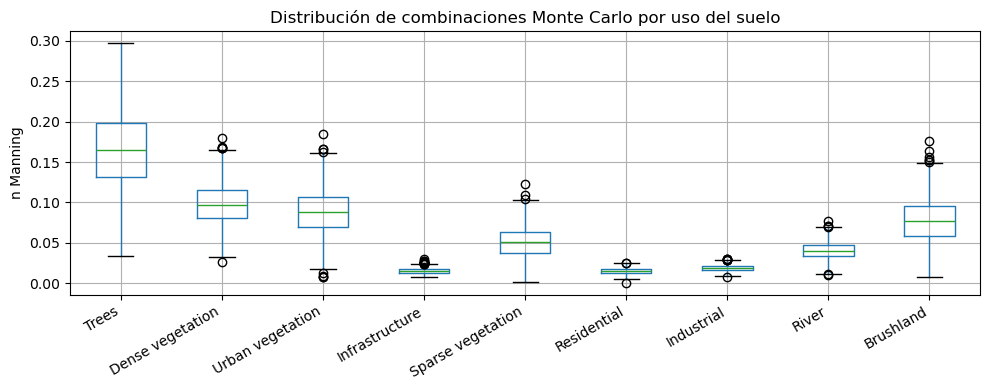

In [9]:
fig, ax = plt.subplots(figsize=(10, 4))
combinaciones_df.boxplot(ax=ax)
ax.set_ylabel("n Manning")
ax.set_title("Distribución de combinaciones Monte Carlo por uso del suelo")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()